In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from joblib import dump
from h5py import File

import csiborgtools

%matplotlib inline
%load_ext autoreload
%autoreload 2


In [3]:
csiborgtools.galactic_to_radec_cartesian(117, 4).shape

(3,)

In [12]:
fpath = "/mnt/extraspace/rstiskalek/catalogs/PV_compilation.hdf5"
# fpath = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TFR.hdf5"

with File(fpath, 'r') as f:
    # mag  = f["w1"][...]
    # eta = f["lgWmxi"][...] - 2.5
    # Qw = f["Qw"][...]
    # RA = f["RA"][...] * 360 / 24
    # DEC = f["DE"][...]
    # print(f.keys())
    RA_2MTF = f["2MTF/RA"][...]
    DEC_2MTF = f["2MTF/DEC"][...]

# m = (mag > 5) & (Qw == 5)
# mag, eta = mag[m], eta[m]
# RA, DEC = RA[m], DEC[m]

# RA = f["2MTF/RA"][...]
# DEC = f["2MTF/DEC"][...]

In [10]:
seed = 30
nsamples = 10000
gen = np.random.default_rng(seed)
RA = gen.uniform(0, 360, nsamples)
DEC = np.rad2deg(np.arcsin(gen.uniform(-1, 1, nsamples)))

In [13]:
!rm /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/*


reader = csiborgtools.read.Carrick2015Field()
velocity = reader.velocity_field()
boxsize = csiborgtools.simname2boxsize("Carrick2015")

# mean_mag = 10.31
# std_mag = 0.83
mean_mag, std_mag = 13.4, 0.5
mean_eta, std_eta = 0.0013264308311763035, 0.1565672419944486
a_TF = -21.5
b_TF = -3
h = 1.0
beta = 0.0
nrepeat_calibration = 2

kmax = 1
seed = 42

# a_TF_dipole = np.asarray([-0.02818924,  0.05263123, 0.00594312])
a_TF_dipole_mag = 0
a_TF_dipole_l =150
a_TF_dipole_b = 30


nsamples = 1500

for k in trange(kmax):
    gen = np.random.default_rng(seed)
    if nsamples is None:
        RA = RA_2MTF
        DEC = DEC_2MTF
    else:
        RA = gen.uniform(0, 360, nsamples)
        DEC = np.rad2deg(np.arcsin(gen.uniform(-1, 1, nsamples)))

    mock, truths = csiborgtools.flow.mock_Carrick2MTF(
        velocity, boxsize, RA, DEC,
        Vext_mag=250, Vext_l=300, Vext_b=-4,
        a_TF_dipole_mag=0, a_TF_dipole_l=150, a_TF_dipole_b=30,
        mean_mag=mean_mag, std_mag=std_mag,
        mean_eta=mean_eta, std_eta=std_eta,
        h=h, a_TF=a_TF, b_TF=b_TF, sigma_TF=0.2,
        sigma_cal=0.2, sigma_v=250,
        nrepeat_calibration=nrepeat_calibration, beta=beta,
        calibration_max_percentile=None, calibration_rand_fraction=None,
        seed=seed, verbose=True, return_truths=True)
    seed += 1

    fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed{k}.hdf5"  # noqa
    print("Saving to ", fname)
    with File(fname, 'w') as f:
        for key in mock.keys():
            f.create_dataset(key, data=mock[key])

    fname_truths = fname.replace(".hdf5", "_truths.pkl")
    dump(truths, fname_truths)

rm: cannot remove '/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/*': No such file or directory


100%|██████████| 1/1 [00:00<00:00, 12.88it/s]

92 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed0.hdf5


In [14]:
mock["r"].max()

294.69388969946976

In [15]:
len(mock['r'])

1500

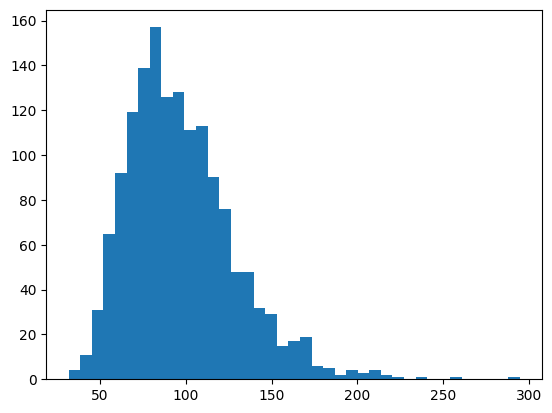

In [16]:
plt.figure()
plt.hist(mock["r"], bins="auto")

plt.show()